# **Simple Linear Regression**

Simple linear regression for a dataset read from a csv file. We applied closed form equations to determine theta1 and theta0 (James et al., 2021). We have three datasets: CASF-2016 Ki (de Azevedo et al., 2024), Advertising dataset (James et al., 2021), and Amsterdam (Wolf, 2022). This code is for linear models as expressed by the following equation: y = theta0 + theta1*X, where theta0 is the fit intercept and theta1 the  coeficient, theta0 and theta1 are the model’s parameters (Géron, 2023). We employed metrics defined by Walsh et al., 2021 and de Azevedo et al., 2024 to assess the predictive performance of  the regression model.



**References**

de Azevedo WF Jr, Quiroga R, Villarreal MA, da Silveira NJF, Bitencourt-Ferreira G, da Silva AD, Veit-Acosta M, Oliveira PR, Tutone M, Biziukova N, Poroikov V, Tarasova O, Baud S. SAnDReS 2.0: Development of machine-learning models to explore the scoring function space. J Comput Chem.  2024 Jun 20. doi: 10.1002/jcc.27449. Epub ahead of print. PMID: 38900052.

Géron, Aurélien. 2023. Hands-on Machine Learning with Scikit-Learn, Keras,
and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems.
3rd ed. CA 95472: O’Reilly.

James, G., Witten, D., Hastie, T., & Tibshirani, R. 2021. An introduction to
statistical learning: With applications in R (2nd ed.). Springer.

Walsh I, Fishman D, Garcia-Gasulla D, Titma T, Pollastri G; ELIXIR Machine
Learning Focus Group, Harrow J, Psomopoulos FE, # Tosatto SCE. DOME:
recommendations for supervised machine learning validation in biology.
Nat Methods. 2021, 18(10), 1122-1127. doi: 10.1038/s41592-021-01205-4

Wolf, Andrew. 2022. The Machine Learning Simplified: A Gentle Introduction to
Supervised Learning. Andrew Wolf. Kindle Edition.

It follows the code to carry out linear regression.


Downloaded csv file: CASF-2016_Ki_training.csv


Determining metrics...Simple linear regression model
Dataset file: CASF-2016_Ki_training.csv
Target variable: pKi
Attribute (independent variable): Gauss 2
Number of instances: 991
Regression model: pKi = 3.94685549 + 0.00216420*Gauss 2
Standard error (theta0) = 0.14913000
Standard error (theta1) = 0.00010911
RSS = 3003.25059071
r = 0.53346783		p-value = 5.33468e-01
rho = 0.52655021	p-value = 8.90738e-72
RMSE = 1.74084041
MAE = 1.24527741
R2 = 0.28458792
DOME = 2.25677992
EDOMEr2 = 2.36746067
EDOMErho = 2.36968685
EDOME = 2.41433733

Metrics defined in the following references:
de Azevedo WF Jr, Quiroga R, Villarreal MA, da Silveira NJF,Bitencourt-Ferreira G, da Silva AD, Veit-Acosta M, Oliveira PR, Tutone M, Biziukova N, Poroikov V, Tarasova O, Baud S. SAnDReS 2.0: Development of machine-learning models to explore  the scoring function space. J Comput Chem. 2024 Jun 20. doi: 10.1002/jcc.27449. Epub ahead of print. PMID: 38900052.

Walsh

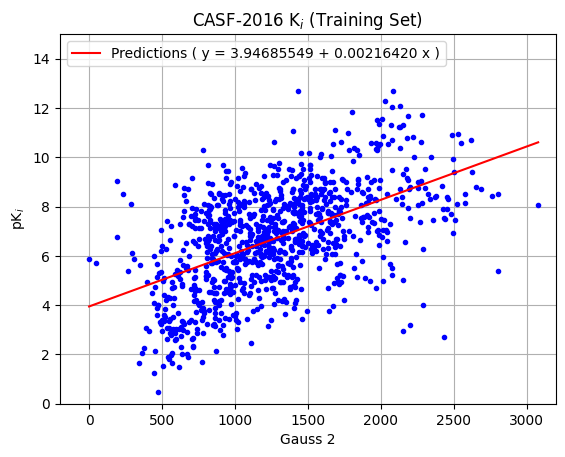

done!
Output scatter plot file: CASF-2016_Ki_training_scatter_plot.png


Generating contour plot...

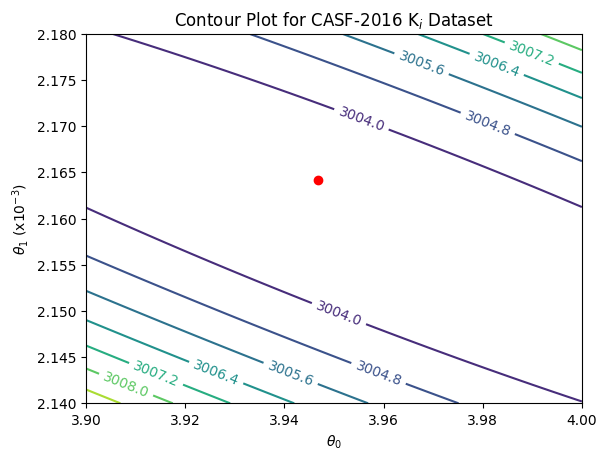

done!
Output contour plot file: CASF-2016_Ki_training_contour_plot.png


Generating 3D plot...

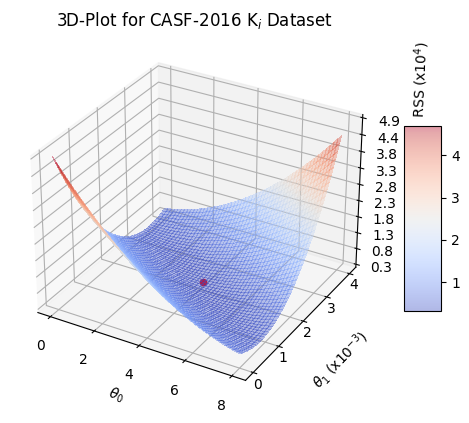

done!
Output 3D-plot file: CASF-2016_Ki_training_3d_surface_plot.png


Writing predicted values for pKi...done!
Output csv file: CASF-2016_Ki_training_predicted_values.csv



<Figure size 640x480 with 0 Axes>

In [1]:
#!/usr/bin/env python3
#
################################################################################
# Dr. Walter F. de Azevedo, Jr.                                                #
# https://github.com/azevedolab                                                #
# July 20, 2024                                                                #
################################################################################
#
# Import section
import urllib.request
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import numpy as np
import csv
from scipy import stats
from sklearn.metrics import median_absolute_error

################################################################################
# CASF-2016 Ki Dataset                                                         #
# de Azevedo WF Jr, Quiroga R, Villarreal MA, da Silveira NJF,                 #
# Bitencourt-Ferreira G, da Silva AD, Veit-Acosta M, Oliveira PR, Tutone M,    #
# Biziukova N, Poroikov V, Tarasova O, Baud S. SAnDReS 2.0: Development of     #
# machine-learning models to explore the scoring function space. J Comput Chem.#
# 2024 Jun 20. doi: 10.1002/jcc.27449. Epub ahead of print. PMID: 38900052.    #
################################################################################

################################################################################
# CASF-2016 Ki (Full Dataset)                                                  #
################################################################################
#file_in = "CASF-2016_Ki.csv"
#url = "https://drive.usercontent.google.com/u/0/uc?id=1JRcUBVjV99E8jAjvEOdilCl4nXS6sNIg&export=download"

################################################################################
# CASF-2016 Ki (Test Set)                                                      #
################################################################################
#file_in = "CASF-2016_Ki_test.csv"
#url = "https://drive.usercontent.google.com/u/0/uc?id=1M-S0Q7AjgKC52FzhrWfHStoXzyV1NSwr&export=download"

################################################################################
# CASF-2016 Ki (Training Set)                                                  #
################################################################################
file_in = "CASF-2016_Ki_training.csv"
url = "https://drive.usercontent.google.com/uc?id=1BLW7UCd1X0C0xP1ZCsCMp79ZzHpM7ix6&export=download"

# Parameters for this dataset
target_label = "pKi"            # Define header for column with target data
attribute_label = "Gauss 2"     # Define header for colums with attribute data

# Scatter plot (inputs for the training set)
plt_scatter_X_min,plt_scatter_X_max,plt_scatter_y_min,plt_scatter_y_max = \
                -200,3200,0,15              # Limits to define plotting
plt_scatter_X_label_str,plt_scatter_y_label_str = \
                        "Gauss 2","pK$_i$"  # Define labels for X and y axes
plt_scatter_title_str = \
        "CASF-2016 K$_i$ (Training Set)"    # Plot title

# Contour plot (inputs for the training set)
plt_countour_n_points = 100
plt_contour_t0_array = [3.9,4]              # Limits to define plotting
plt_contour_t1_array = [0.00214,0.00218]    # [theta_min,theta_max]
plt_contour_t0_factor = 1.0                 # Scaling to make nice plots
plt_contour_t1_factor = 1000                # Scaling to make nice plots
plt_contour_t0_label = "$\\theta_{0}$"      # Theta0 axis label
plt_contour_t1_label =\
            "$\\theta_{1}$ (x10$^{-3}$)"    # Theta1 axis label
plt_contour_title = \
"Contour Plot for CASF-2016 K$_i$ Dataset"  # Plot title

# 3D plot (inputs for the training set)
plt_3d_n_points = 800                       # Number of points for 3D-plotting
plt_3d_t0_array = [0,8,0.01]                # Limits to define plotting
plt_3d_t1_array = [0,0.004,0.000005]        # [theta_min,theta_max,step]
plt_3d_t0_factor = 1.0                      # Scaling to make nice plots
plt_3d_t1_factor = 1000                     # Scaling to make nice plots
plt_3d_rss_factor = 1e-4                    # Scaling to make nice plots
plt_3d_t0_label = "$\\theta_{0}$"           # Theta0 axis label
plt_3d_t1_label = \
            "$\\theta_{1}$ (x10$^{-3}$)"    # Theta1 axis label
plt_3d_z_label = \
            "\t\t\t\t\t\tRSS (x10$^4$)"     # Z axis label
plt_3d_tick_params_axis = "y"               # Define axis for moving tick marks
plt_3d_tick_params_pad = -5                 # Define pad for moving tick marks
plt_3d_tick_params_rot = 0                  # Define rotation for tick marks
plt_3d_title = \
"3D-Plot for CASF-2016 K$_i$ Dataset"       # Plot title

################################################################################
# Advertising Dataset                                                          #
# James, G., Witten, D., Hastie, T., & Tibshirani, R. 2021. An introduction to #
# statistical learning: With applications in R (2nd ed.). Springer.            #
################################################################################
#file_in = "Advertising.csv"
#url = "https://www.statlearning.com/s/Advertising.csv"

# Parameters for this dataset
#target_label = "sales"            # Define header for column with target data
#attribute_label = "TV"            # Define header for colums with attribute data

# Scatter plot
#plt_scatter_X_min,plt_scatter_X_max,plt_scatter_y_min,plt_scatter_y_max = \
#                -10,310,0,30                # Limits to define plotting
#plt_scatter_X_label_str,plt_scatter_y_label_str = \
#                        "TV","Sales"        # Define labels for X and y axes
#plt_scatter_title_str = \
#        "Advertising Dataset"               # Plot title

# Contour plot
#plt_countour_n_points = 100
#plt_contour_t0_array = [7.0,7.07]           # Limits to define plotting
#plt_contour_t1_array = [0.045,0.05]         # [theta_min,theta_max]
#plt_contour_t0_factor = 1.0                 # Scaling to make nice plots
#plt_contour_t1_factor = 1.0                 # Scaling to make nice plots
#plt_contour_t0_label = "$\\theta_{0}$"      # Theta0 axis label
#plt_contour_t1_label =\
#            "$\\theta_{1}$"                 # Theta1 axis label
#plt_contour_title = \
#"Contour Plot for Advertising Dataset"      # Plot title

# 3D plot
#plt_3d_n_points = 800                       # Number of points for 3D-plotting
#plt_3d_t0_array = [0,12,0.015]              # Limits to define plotting
#plt_3d_t1_array = [0,0.08,0.0001]           # [theta_min,theta_max,step]
#plt_3d_t0_factor = 1.0                      # Scaling to make nice plots
#plt_3d_t1_factor = 1.0                      # Scaling to make nice plots
#plt_3d_rss_factor = 1e-4                    # Scaling to make nice plots
#plt_3d_t0_label = "$\\theta_{0}$"           # Theta0 axis label
#plt_3d_t1_label = \
#            "$\\theta_{1}$"                 # Theta1 axis label
#plt_3d_z_label = \
#            "\t\t\t\t\t\tRSS (x10$^4$)"     # Z axis label
#plt_3d_tick_params_axis = "y"               # Define axis for moving tick marks
#plt_3d_tick_params_pad = 0                  # Define pad for moving tick marks
#plt_3d_tick_params_rot = 0                  # Define rotation for tick marks
#plt_3d_title = \
#"3D-Plot for Advertising Dataset"           # Plot title

################################################################################
# Amsterdam Dataset                                                            #
# Wolf, Andrew. 2022. The Machine Learning Simplified: A Gentle Introduction   #
# to Supervised Learning. Andrew Wolf. Kindle Edition.                         #
################################################################################

################################################################################
# Amsterdam (Full Dataet)                                                      #
################################################################################
#file_in = "Amsterdam_apartments.csv"
#url = "https://drive.usercontent.google.com/u/0/uc?id=1P4gFiPHLrkEa0ldSO8CVlkbffgPBT5_G&export=download"

################################################################################
# Amsterdam (Test Set)                                                         #
################################################################################
#file_in = "Amsterdam_apartments_test_set.csv"
#url = "https://drive.usercontent.google.com/u/0/uc?id=1XmFu9f7mkYC3eXieUF4qkP8m8FIWWfC6&export=download"

################################################################################
# Amsterdam (Training Set)                                                     #
################################################################################
#file_in = "Amsterdam_apartments_training_set.csv"
#url = "https://drive.usercontent.google.com/u/0/uc?id=1coimgPJyo3E_e03WQCu-XKK8qChbUan3&export=download"

# Parameters for this dataset
#target_label = "Price"            # Define header for column with target data
#attribute_label = "Area"          # Define header for colums with attribute data

# Scatter plot (inputs for the training set)
#plt_scatter_X_min,plt_scatter_X_max,plt_scatter_y_min,plt_scatter_y_max = \
#                20,120,0,140                # Limits to define plotting
#plt_scatter_X_label_str,plt_scatter_y_label_str = \
#                        "Area","Price"      # Define labels for X and y axes
#plt_scatter_title_str = \
#        "Amsterdam Dataset"                 # Plot title

# Contour plot (inputs for the training set)
#plt_countour_n_points = 500
#plt_contour_t0_array = [-20,-16]            # Limits to define plotting
#plt_contour_t1_array = [1.2,1.4]            # [theta_min,theta_max]
#plt_contour_t0_factor = 1.0                 # Scaling to make nice plots
#plt_contour_t1_factor = 1.0                 # Scaling to make nice plots
#plt_contour_t0_label = "$\\theta_{0}$"      # Theta0 axis label
#plt_contour_t1_label =\
#            "$\\theta_{1}$"                 # Theta1 axis label
#plt_contour_title = \
#"Contour Plot for Amsterdam Dataset"        # Plot title

# 3D plot (inputs for the training set)
#plt_3d_n_points = 1000                      # Number of points for 3D-plotting
#plt_3d_t0_array = [-25,-10,0.015]           # Limits to define plotting
#plt_3d_t1_array = [0,2.5,0.0025]            # [theta_min,theta_max,step]
#plt_3d_t0_factor = 1.0                      # Scaling to make nice plots
#plt_3d_t1_factor = 1.0                      # Scaling to make nice plots
#plt_3d_rss_factor = 1e-4                    # Scaling to make nice plots
#plt_3d_t0_label = "$\\theta_{0}$"           # Theta0 axis label
#plt_3d_t1_label = \
#            "$\\theta_{1}$"                 # Theta1 axis label
#plt_3d_z_label = \
#            "\t\t\t\t\t\tRSS (x10$^4$)"     # Z axis label
#plt_3d_tick_params_axis = "y"               # Define axis for moving tick marks
#plt_3d_tick_params_pad = -4                 # Define pad for moving tick marks
#plt_3d_tick_params_rot = 0                  # Define rotation for tick marks
#plt_3d_title = \
#"3D-Plot for Amsterdam Dataset"             # Plot title

################################################################################
# Download and read a csv file
print("Downloading file: "+file_in,end="...")
filename, headers = urllib.request.urlretrieve(url, filename=file_in)
fo = open(file_in,"r")
csv_in = csv.reader(fo)
for line in csv_in:
    i_y = line.index(target_label)
    i_X = line.index(attribute_label)
    break
fo.close()

# Get numerical data
data = np.genfromtxt(file_in, delimiter=',', skip_header = 1)
X = data[:,i_X]
X_3d = X            # To have the original version for 3D-plotting
y = data[:,i_y]
print("done!")
msg_out = "Downloaded csv file: "+file_in
print(msg_out+"\n")
################################################################################
# Calculate parameters (theta0,theta1) as defined elsewhere
# James, G., Witten, D., Hastie, T., & Tibshirani, R. 2021. An introduction to
# statistical learning: With applications in R (2nd ed.). Springer.
X_bar = X.mean()
y_bar = y.mean()
theta1 = np.sum( (X - X_bar)*(y - y_bar) )/np.sum( (X - X_bar)**2 )
theta0 = y_bar - theta1*X_bar

################################################################################
# Make predictions
X_array = np.array([[X.min()],[X.max()]])
y_linear = theta0 + theta1*X_array
y_pred = theta0 + theta1*X

################################################################################
# Determine metrics
print("\nDetermining metrics",end="...")
file_metrics = file_in.replace(".csv","_metrics.log")
fo_metrics = open(file_metrics,"w")
n = len(y)
rss_min = np.sum( np.square(y_pred - y) )
rmse =  np.sqrt( (np.sum( (y - y_pred)**2 ))/n )
mae = median_absolute_error(y,y_pred)
ss_res = np.sum( (y - y_pred)**2 )
ss_tot = np.sum( (y - y_bar)**2 )
R2 = 1 - ss_res/ss_tot

# Standard error as defined in James, G., Witten, D., Hastie, T., & Tibshirani,
# R. 2021. An introduction to statistical learning: With applications in R
# (2nd ed.). Springer.
s2 = rss_min/(n - 2)
se_theta0_2 = s2*(1/n + (X_bar**2)/np.sum( (X - X_bar)**2)  )
se_theta1_2 = s2/np.sum( (X - X_bar)**2)
se_theta0,se_theta1 = np.sqrt(se_theta0_2),np.sqrt(se_theta1_2)

# Alternative approach to detemine standard errors for a regression model
#import statsmodels.api as sm
#X_b = np.c_[np.ones((len(X),1)),X] # Add 1 to each instance
#ols = sm.OLS(y, X_b)
#ols_result = ols.fit()
#se_theta0,se_theta1 = ols_result.bse

r_pearson,p_pearson = stats.pearsonr(y,y_pred)
rho,p_spearman = stats.spearmanr(y,y_pred)
dome = np.sqrt(rmse**2 + mae**2 + (R2 -1)**2 )
edomer2 = np.sqrt(rmse**2 + mae**2 + (R2 -1)**2 + (r_pearson**2 - 1)**2)
edomerho = np.sqrt(rmse**2 + mae**2 + (R2 -1)**2 + (rho**2 - 1)**2)
edome = np.sqrt(rmse**2 + mae**2+(R2-1)**2 +(r_pearson**2-1)**2 +(rho-1)**2)
metrics_out = "Simple linear regression model"
metrics_out += "\nDataset file: "+file_in
metrics_out += "\nTarget variable: "+target_label
metrics_out += "\nAttribute (independent variable): "+attribute_label
metrics_out += "\nNumber of instances: "+str(n)
metrics_out += "\nRegression model: "+target_label+" = {:.8f}".format(theta0)
metrics_out += " + {:.8f}*".format(theta1)+attribute_label
metrics_out += "\nStandard error (theta0) = {:.8f}".format(se_theta0)
metrics_out += "\nStandard error (theta1) = {:.8f}".format(se_theta1)
metrics_out += "\nRSS = {:.8f}".format(rss_min)
metrics_out +="\nr = {:.8f}".format(r_pearson)
metrics_out += "\t\tp-value = {:.5e}".format(r_pearson)
metrics_out += "\nrho = {:.8f}".format(rho)
metrics_out += "\tp-value = {:.5e}".format(p_spearman)
metrics_out += "\nRMSE = {:.8f}".format(rmse)
metrics_out += "\nMAE = {:.8f}".format(mae)
metrics_out += "\nR2 = {:.8f}".format(R2)
metrics_out += "\nDOME = {:.8f}".format(dome)
metrics_out += "\nEDOMEr2 = {:.8f}".format(edomer2)
metrics_out += "\nEDOMErho = {:.8f}".format(edomerho)
metrics_out += "\nEDOME = {:.8f}".format(edome)
metrics_out += "\n\nMetrics defined in the following references:"
metrics_out += "\nde Azevedo WF Jr, Quiroga R, Villarreal MA, da Silveira NJF,"
metrics_out += "Bitencourt-Ferreira G, da Silva AD, Veit-Acosta M, Oliveira PR,"
metrics_out += " Tutone M, Biziukova N, Poroikov V, Tarasova O, Baud S. "
metrics_out += "SAnDReS 2.0: Development of machine-learning models to explore "
metrics_out += " the scoring function space. J Comput Chem. 2024 Jun 20. "
metrics_out += "doi: 10.1002/jcc.27449. Epub ahead of print. PMID: 38900052.\n"
metrics_out += "\nWalsh I, Fishman D, Garcia-Gasulla D, Titma T, Pollastri G; "
metrics_out += "ELIXIR Machine Learning Focus Group, Harrow J, Psomopoulos FE, "
metrics_out += "Tosatto SCE. DOME: recommendations for supervised machine "
metrics_out += "learning validation in biology. Nat Methods. 2021, 18(10), "
metrics_out += "1122-1127. doi: 10.1038/s41592-021-01205-4\n"
fo_metrics.write(metrics_out)
fo_metrics.close()
print(metrics_out)
print("done!")
msg_out = "Output log file: "+file_metrics
print(msg_out+"\n")
################################################################################
# Set up plot parameters to generate a scatter plot
print("\nGenerating scatter plot",end="...")
theta0_str = "{:.8f}".format(theta0)
theta1_str = "{:.8f}".format(theta1)
plt_label_str = "Predictions ( y = "+theta0_str+" + "+theta1_str+" x )"
plt_str_1 = "b."
plt_str_2 = "r-"
plt_axis_array = [plt_scatter_X_min,plt_scatter_X_max,plt_scatter_y_min,
                                                            plt_scatter_y_max]
plt_legend_loc = "upper left"
plt_grid_boolean = True
plt_scatter_file = file_in.replace(".csv","_scatter_plot.png")
plt_dpi = 1200

# Generate scatter plot
plt.plot(X, y,plt_str_1)                                    # Experimental data
plt.plot(X_array,y_linear,plt_str_2,label=plt_label_str)    # Predictions
plt.axis(plt_axis_array)                                    # Limits of axis
plt.xlabel(plt_scatter_X_label_str)                         # X label
plt.ylabel(plt_scatter_y_label_str)                         # y label
plt.legend(loc = plt_legend_loc)                            # Legend location
plt.grid(visible = plt_grid_boolean)                        # Add grid to plot
plt.title(plt_scatter_title_str)                            # Plot title
plt.show()                                                  # Show plot
plt.savefig(plt_scatter_file,dpi=plt_dpi)                   # Save plot
plt.close()
print("done!")
msg_out = "Output scatter plot file: "+plt_scatter_file
print(msg_out+"\n")
################################################################################
# Set up plot parameters to generate a contour plot
print("\nGenerating contour plot",end="...")
plt_contour_file = file_in.replace(".csv","_contour_plot.png")
t0 = np.linspace(plt_contour_t0_array[0],plt_contour_t0_array[1],
                                                    plt_countour_n_points)
t1 = np.linspace(plt_contour_t1_array[0],plt_contour_t1_array[1],
                                                    plt_countour_n_points)
rss = []
for i in range(len(t0)):
    for j in range(len(t1)):
        y_full_predictions = t0[i] + t1[j]*X
        rss_value = np.sum( np.square(y_full_predictions - y)   )
        rss.append(rss_value)

# Generate contour plot
X, Y = np.meshgrid(t0,t1)   # Return a tuple of coordinate matrices from
                            # coordinate vectors
Z = np.array(rss)                               # Generate a NumPy array
Z = Z.reshape(plt_countour_n_points,
                    plt_countour_n_points)      # Reshape array
fig, ax = plt.subplots()                        # Set up plot
CS = ax.contour(X*plt_contour_t0_factor,
Y*plt_contour_t1_factor,Z)                      # Set up contour plot
ax.scatter(theta0,theta1*plt_contour_t1_factor,marker="o",
                                        c="r")  # Minimum of RSS
ax.clabel(CS, inline=True, fontsize=10)         # Define font size
ax.set_xlabel(plt_contour_t0_label)             # X label
ax.set_ylabel(plt_contour_t1_label)             # y label
ax.set_title(plt_contour_title)                 # Plot title
plt.show()                                      # Show plot
plt.savefig(plt_contour_file,dpi=plt_dpi)       # Save plot
plt.close()
print("done!")
msg_out = "Output contour plot file: "+plt_contour_file
print(msg_out+"\n")
################################################################################
# Set up plot parameters for 3D plot
print("\nGenerating 3D plot",end="...")
plt_3d_surface_file = file_in.replace(".csv","_3d_surface_plot.png")
t0 = np.arange(plt_3d_t0_array[0],plt_3d_t0_array[1],plt_3d_t0_array[2])
t1 = np.arange(plt_3d_t1_array[0],plt_3d_t1_array[1],plt_3d_t1_array[2])
rss = []
for i in range(len(t0)):
    for j in range(len(t1)):
        y_full_predictions = t0[i] + t1[j]*X_3d
        rss_value = np.sum( np.square(y_full_predictions - y)   )
        rss.append(rss_value)

# Generate 3D plot
# https://matplotlib.org/stable/gallery/mplot3d/surface3d.html
X, Y = np.meshgrid(t0*plt_3d_t0_factor,
                t1*plt_3d_t1_factor)        # Return a tuple of coordinate
                                            # matrices from coordinate vectors
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}) # Set up plot
Z = np.array(rss)                               # Generate a NumPy array
Z = Z.reshape(plt_3d_n_points,
            plt_3d_n_points)*plt_3d_rss_factor  # Reshape array
ax.scatter(theta0*plt_3d_t0_factor,theta1*plt_3d_t1_factor,
                rss_min*plt_3d_rss_factor, marker="o", c="r") # Minimum of RSS
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, alpha=0.4,linewidth=0,
                            antialiased=False)  # Generate surface plot

# Customize the z axis
ax.set_zlim(Z.min(), Z.max())
ax.zaxis.set_major_locator(LinearLocator(10))

# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter("{x:.1f}")
ax.set_xlabel(plt_3d_t0_label)
ax.set_ylabel(plt_3d_t1_label)
ax.tick_params(axis=plt_3d_tick_params_axis,pad=plt_3d_tick_params_pad,
        rotation=plt_3d_tick_params_rot)    # Define moving data for tick marks
ax.set_zlabel(plt_3d_z_label)

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)        # Set up colorbar
ax.set_title(plt_3d_title)                      # Plot title
plt.show()                                      # Show plot
plt.savefig(plt_3d_surface_file,dpi=plt_dpi)    # Save plot
print("done!")
msg_out = "Output 3D-plot file: "+plt_3d_surface_file
print(msg_out+"\n")
################################################################################
# Write predicted values
print("\nWriting predicted values for "+target_label,end="...")
file_predicted_values = file_in.replace(".csv","_predicted_values.csv")
fo_out = open(file_predicted_values,"w")
data_out = attribute_label+","+target_label+","+target_label+"(predicted)"+"\n"
for i,line in enumerate(y_pred):
    data_out += str(X_3d[i])+","+str(y[i])+","+str(y_pred[i])+"\n"
fo_out.write(data_out)
fo_out.close()
print("done!")
msg_out = "Output csv file: "+file_predicted_values
print(msg_out+"\n")
################################################################################